<a href="https://colab.research.google.com/github/ahmedyussuf4/Fintech_Group_Project_Italy_Spain_Portugal.pptx./blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 4 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

For this assignment, the variable `answered` is your target.  

### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [33]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Initial Data Understanding

### Do the following:
 1. Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 2. Show the datatypes
 3. Describe the dataset

 Think about if there are any outliers, missing values, or duplicates.  We will cover those topics more next week.  

In [34]:
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_historical_data.csv'
df = pd.read_csv(url)
print(df.head())

   customer_id  answered  income female  age  job  num_dependents  rent  \
0        10098         0  -65600      0   24    2               1     0   
1          184         0    4330      0   24    2               2     1   
2          194         0    4330      0   22    2               1     1   
3          689         0    4330      0   24    2               2     1   
4          811         0    4330      0   22    2               1     1   

   own_res  new_car  chk_acct  sav_acct  num_accts  mobile  product  
0        1      1.0         1         1          3       0        0  
1        0      0.0         1         3          1       0        0  
2        0      0.0         3         0          0       0        0  
3        0      0.0         1         3          1       0        0  
4        0      0.0         3         0          0       0        0  


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     29504 non-null  int64  
 1   answered        29504 non-null  int64  
 2   income          29504 non-null  int64  
 3   female          29504 non-null  object 
 4   age             29504 non-null  int64  
 5   job             29504 non-null  int64  
 6   num_dependents  29504 non-null  int64  
 7   rent            29504 non-null  int64  
 8   own_res         29504 non-null  int64  
 9   new_car         29502 non-null  float64
 10  chk_acct        29504 non-null  int64  
 11  sav_acct        29504 non-null  int64  
 12  num_accts       29504 non-null  int64  
 13  mobile          29504 non-null  int64  
 14  product         29504 non-null  int64  
dtypes: float64(1), int64(13), object(1)
memory usage: 3.4+ MB


In [36]:
df.describe()

,customer_id,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,14850.475563,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,8517.254310,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,99.000000,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7474.750000,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,14850.500000,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,22226.250000,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,29602.000000,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


Question 1.4: Do you see any variables that have potential outliers?  What indicators do you see the the values are out of the normal range?  (don't worry about using a scientific approach for outliers at this stage; just use your best judgment)

### ✍️ Your Response: 🔧
1.4. Income stands out right away because row 0 shows -65,600, and income obviously shouldn't be negative. Also, new_car has a couple of missing values and should only be binary, so anything outside of 0 or 1 would be out of range.

# Step 2: Begin to Explore the Data

We will learn more about Exploratory Data Analysis (EDA) in Week 5. The following steps are to help you connect the data visualization steps that we practiced last week with the process of data understanding - learning more about the dataset and finding the data quality issues that need to be addressed.   These are the first steps in EDA.

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

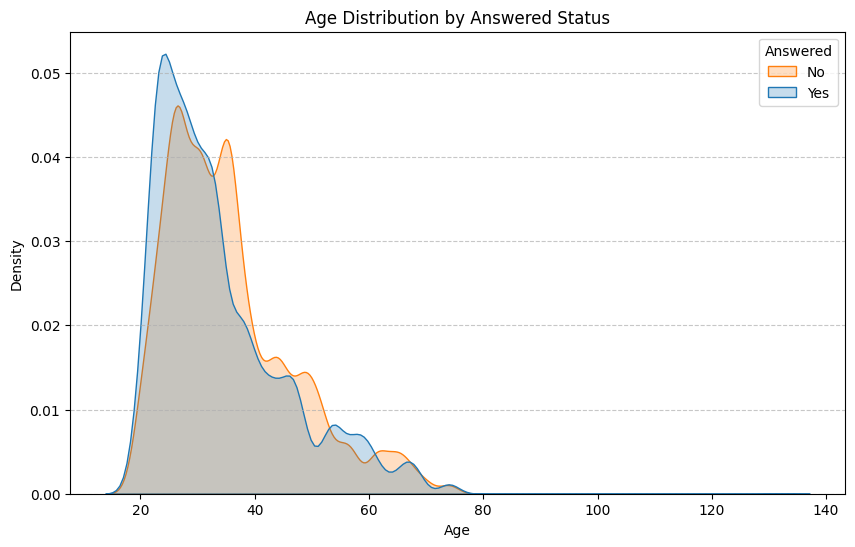

In [37]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='age', hue='answered', fill=True, common_norm=False)
plt.title('Age Distribution by Answered Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Answered', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

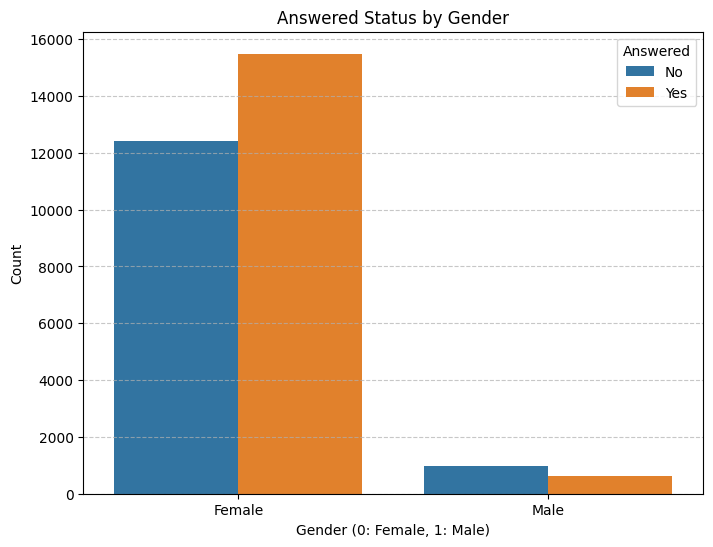

In [38]:
df['female'] = df['female'].astype(str).replace('M', '1').astype(int)
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='female', hue='answered')
plt.title('Answered Status by Gender')
plt.xlabel('Gender (0: Female, 1: Male)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Female', 'Male']) # Custom labels for clarity
plt.legend(title='Answered', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

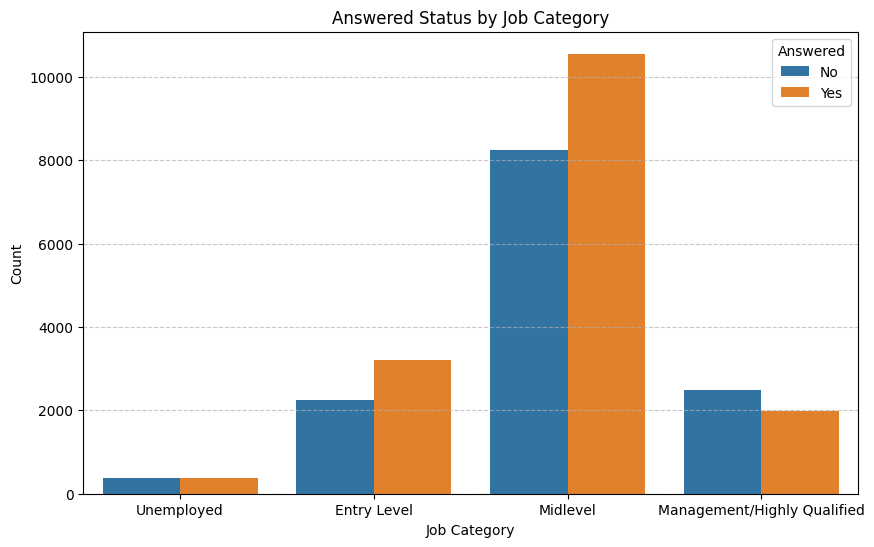

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='job', hue='answered')
plt.title('Answered Status by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Unemployed', 'Entry Level', 'Midlevel', 'Management/Highly Qualified'])
plt.legend(title='Answered', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

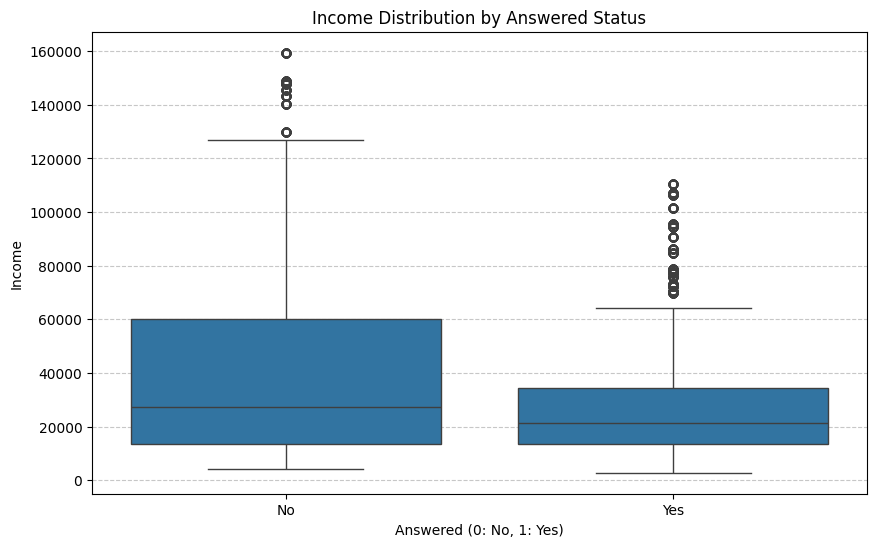

In [40]:
df_filtered_income = df[df['income'] >= 0]
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filtered_income, x='answered', y='income')
plt.title('Income Distribution by Answered Status')
plt.xlabel('Answered (0: No, 1: Yes)')
plt.ylabel('Income')
plt.xticks([0, 1], ['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

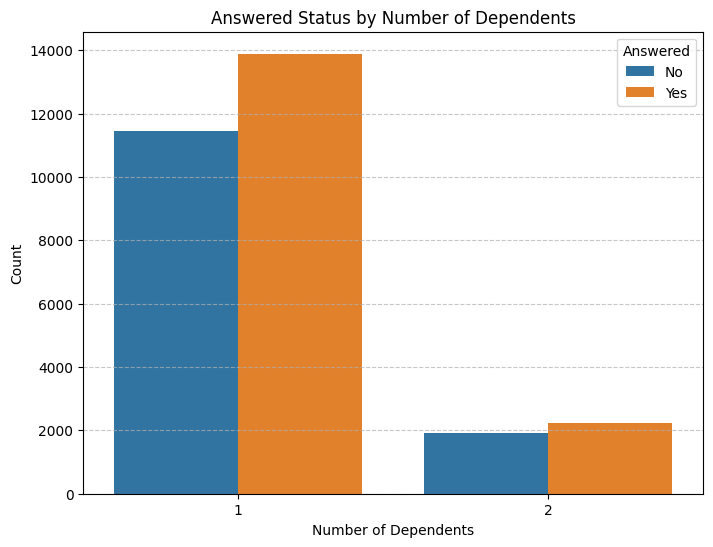

In [41]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='num_dependents', hue='answered')
plt.title('Answered Status by Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Count')
plt.legend(title='Answered', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Step 3: Summarize Your Findings
- Question 3.1: Which variables are NOT useful or applicable to the business need?  (you should reference the target variable and list any variables that are not correlated with the target)

- Question 3.2: Which variables are MOST useful or applicable to the business need, based on the output of your charts?   

- Question 3.3: List at least three ways that the dataset could be improved.  What data quality issues or data types should be fixed?



### ✍️ Your Response: 🔧
3.1 Customer id is not useful since it is a unique identifier with no correlation to the target, and product creates data leakage because it can only be known after a customer answers.

3.2 Variables like job category age and income are the most useful because their visualizations show clear behavioral patterns and splits in response rates.

3.3 Three ways to improve the dataset include cleaning up anomalous negative income entries fixing data types for binary columns like female and handling missing values in fields like new car.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas

In [44]:
!jupyter nbconvert --to html "assignment_04_data_understanding.ipynb"

[NbConvertApp] Converting notebook assignment_04_data_understanding.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 558430 bytes to assignment_04_data_understanding.html
